In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader


wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from src.utils.constants import *

epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = 12, prediction_horizon=1)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = range(2,3))
epidata_nuts2.finalize()

epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts2_bn  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
epidata_nuts2_gm1 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
epidata_nuts2_gm2 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()

GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)
GNN temporal windowing: extending data collection from 2020-06-01 to 2020-08-24 (+12 weeks)



🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 1], edge_index=[2, 38], edge_weight=[38])
Epoch 1 train loss: 0.6501, val loss: 1.0260 ✓ (new best)
Epoch 2 train loss: 0.5151, val loss: 0.6789 ✓ (new best)
Epoch 3 train loss: 0.4200, val loss: 0.5161 ✓ (new best)
Epoch 4 train loss: 0.3731, val loss: 0.4345 ✓ (new best)
Epoch 5 train loss: 0.3372, val loss: 0.3860 ✓ (new best)
Epoch 6 train loss: 0.3147, val loss: 0.3511 ✓ (new best)
Epoch 7 train loss: 0.2971, val loss: 0.3407 ✓ (new best)
Epoch 8 train loss: 0.2835, val loss: 0.3043 ✓ (new best)
Epoch 9 train loss: 0.2748, val loss: 0.3014 ✓ (new best)
Epoch 10 train loss: 0.2720, val loss: 0.2794 ✓ (new best)
Epoch 11 train loss: 0.2583, val loss: 0.2770 ✓ (new best)
Epoch 12 train loss: 0.2555, val loss: 0.2591 ✓ (new best)
Epoch 13 train loss: 0.2526, val loss: 0.2585 ✓ 

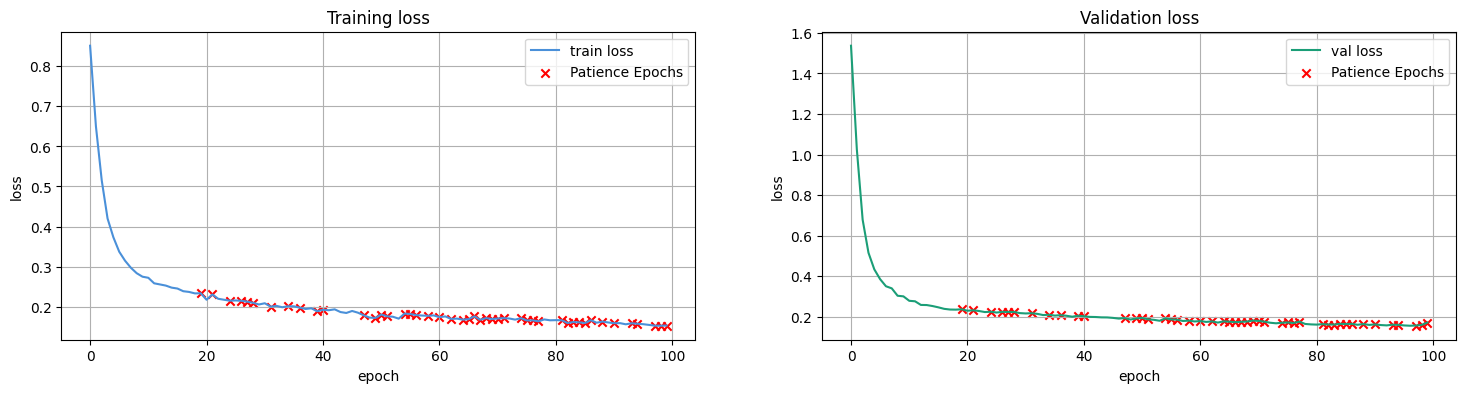

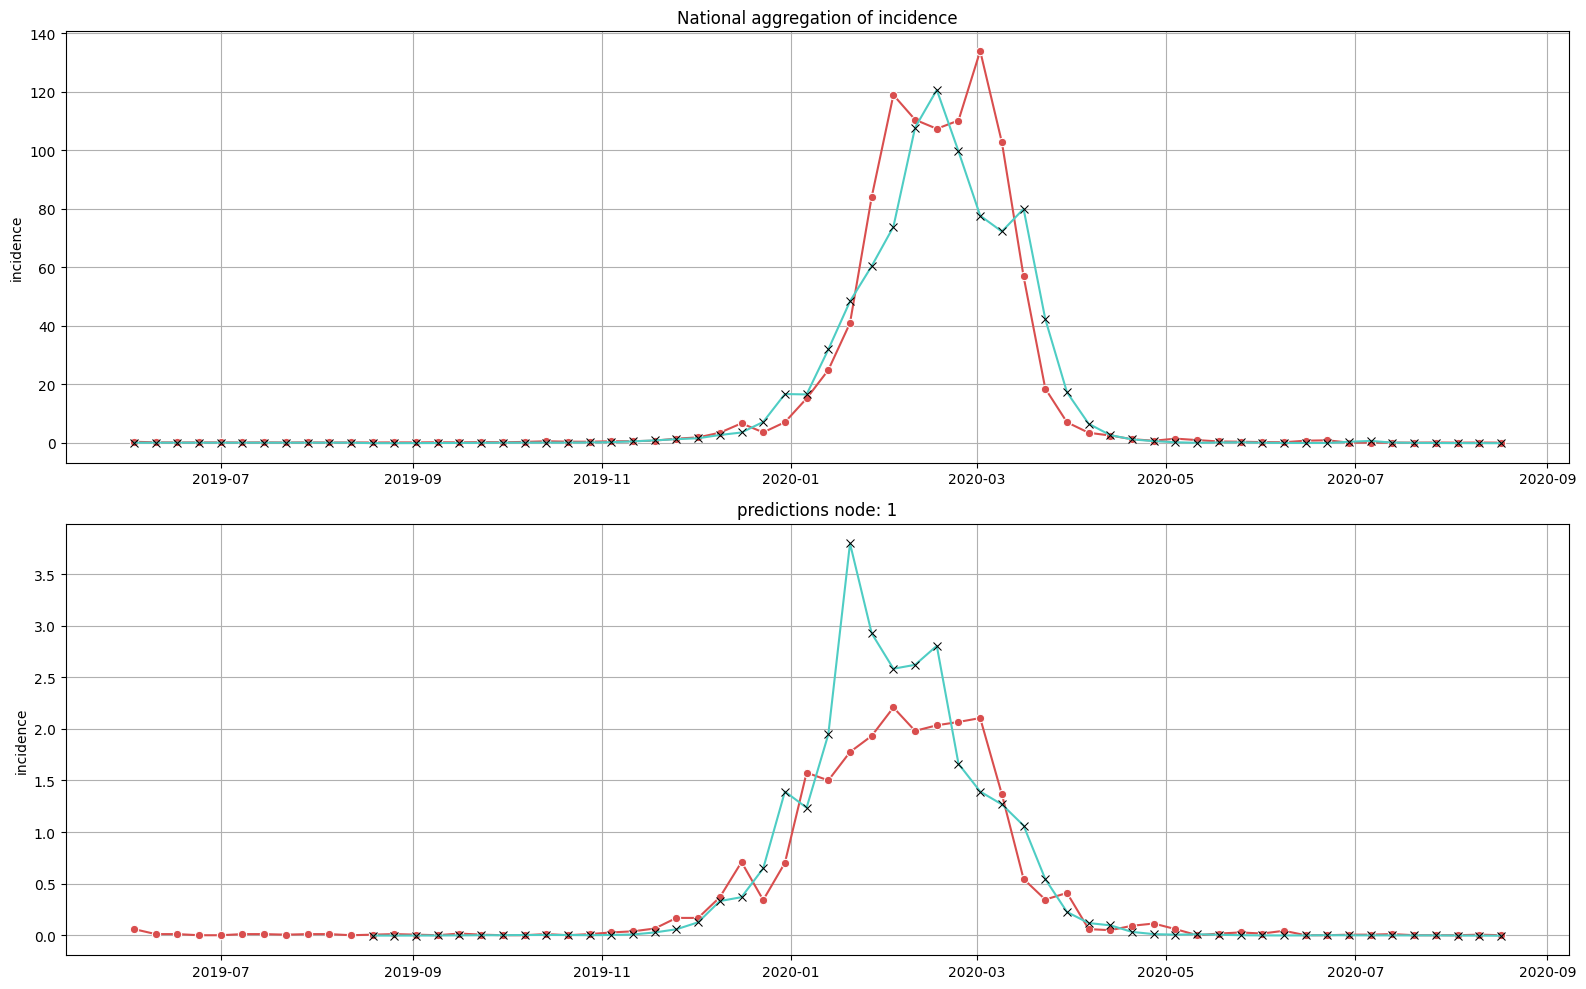


🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 1], edge_index=[2, 172], edge_weight=[172])
Epoch 1 train loss: 0.6729, val loss: 1.0670 ✓ (new best)
Epoch 2 train loss: 0.5464, val loss: 0.7359 ✓ (new best)
Epoch 3 train loss: 0.4513, val loss: 0.5679 ✓ (new best)
Epoch 4 train loss: 0.3968, val loss: 0.4792 ✓ (new best)
Epoch 5 train loss: 0.3601, val loss: 0.4230 ✓ (new best)
Epoch 6 train loss: 0.3340, val loss: 0.3903 ✓ (new best)
Epoch 7 train loss: 0.3086, val loss: 0.3667 ✓ (new best)
Epoch 8 train loss: 0.2996, val loss: 0.3453 ✓ (new best)
Epoch 9 train loss: 0.2963, val loss: 0.3448 ✓ (new best)
Epoch 10 train loss: 0.2886, val loss: 0.3379 ✓ (new best)
Epoch 11 train loss: 0.2767, val loss: 0.3216 ✓ (new best)
Epoch 12 train loss: 0.2719, val loss: 0.3230 (patience: 1/15)
Epoch 13 train loss: 0.2723, val loss: 0.3

KeyboardInterrupt: 

In [3]:
from src.models.spatiotemporal_baseline import TGCNModel

n_epochs = 100
lr       = 0.0001

ml2_id = TGCNModel(name = f'tgcn-identity_graph', dataloader=epidata_nuts2_id)
ml2_id.set_model_hparams()
ml2_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_id.run_snapshot(debug=True)
ml2_id.train(verbose=2)
ml2_id.forecast()
ml2_id.show_forecasts(dataset='test', target_h = 0)

ml2_bn = TGCNModel(name = f'tgcn-boolean_neighbors', dataloader=epidata_nuts2_bn)
ml2_bn.set_model_hparams()
ml2_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_bn.run_snapshot(debug=True)
ml2_bn.train(verbose=2)
ml2_bn.forecast()
ml2_bn.show_forecasts(dataset='test', target_h = 0)

ml2_gm1 = TGCNModel(name = f'tgcn-gravity1', dataloader=epidata_nuts2_gm1)
ml2_gm1.set_model_hparams()
ml2_gm1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_gm1.run_snapshot(debug=True)
ml2_gm1.train(verbose=2)
ml2_gm1.forecast()
ml2_gm1.show_forecasts(dataset='test', target_h = 0)

ml2_gm2 = TGCNModel(name = f'tgcn-gravity2', dataloader=epidata_nuts2_gm2)
ml2_gm2.set_model_hparams()
ml2_gm2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_gm2.run_snapshot(debug=True)
ml2_gm2.train(verbose=2)
ml2_gm2.forecast()
ml2_gm2.show_forecasts(dataset='test', target_h = 0)